In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
print(df.shape)

(150, 5)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

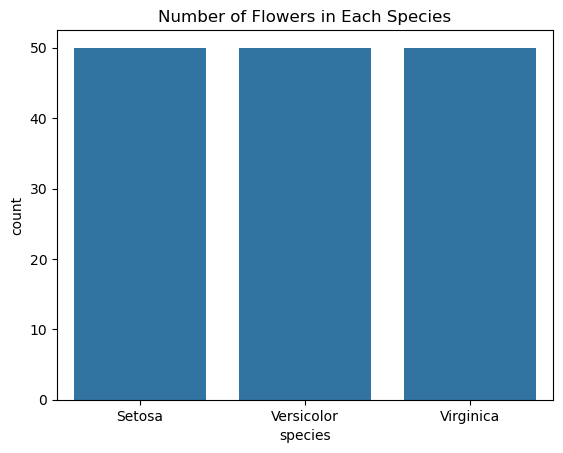

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="species", data=df)
plt.title("Number of Flowers in Each Species")
plt.show()

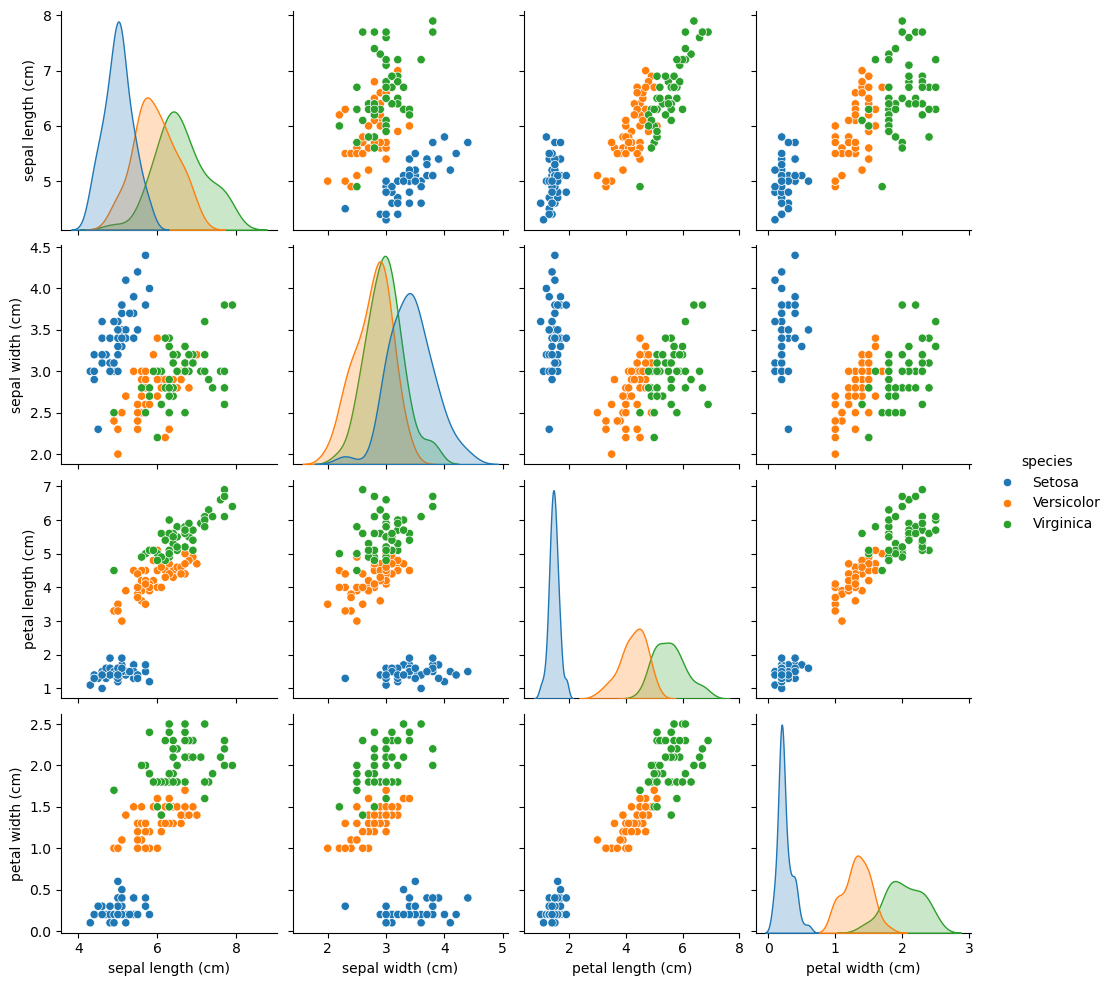

In [10]:
sns.pairplot(df, hue="species")
plt.show()

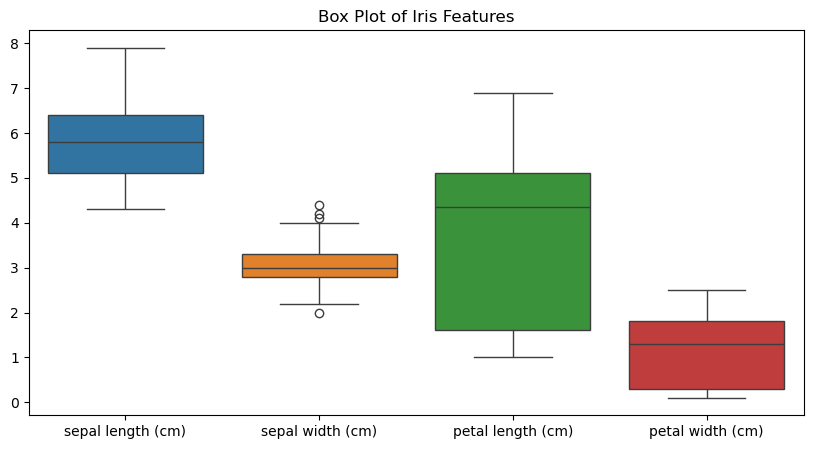

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.title("Box Plot of Iris Features")
plt.show()

In [12]:
df2 = df.copy()
df2["species"] = df2["species"].map({
    "Setosa": 0,
    "Versicolor": 1,
    "Virginica": 2
})

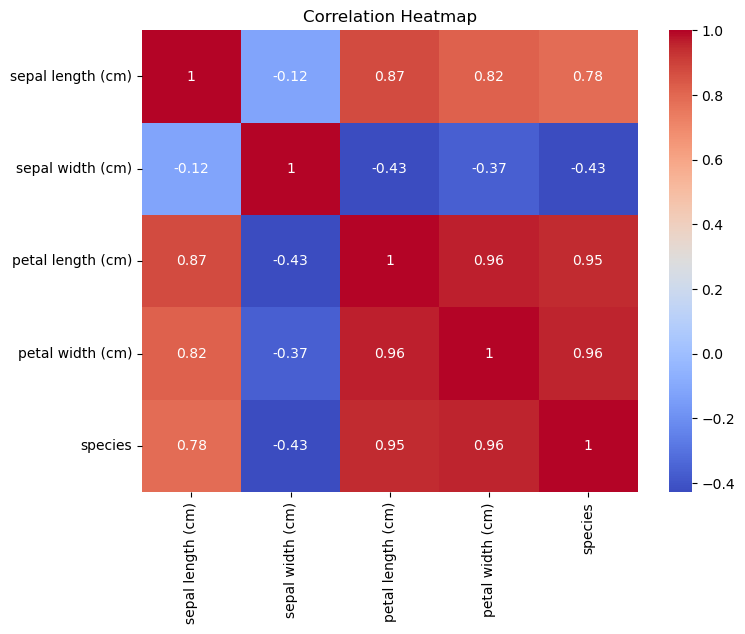

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Input features
X = df.drop("species", axis=1)

# Output (Target)
y = df["species"]

print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: species, dtype: object


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [16]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=200)

model1.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [17]:
prediction = model1.predict(X_test)

print(prediction)

['Versicolor' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa'
 'Versicolor' 'Virginica' 'Versicolor' 'Versicolor' 'Virginica' 'Setosa'
 'Setosa' 'Setosa' 'Setosa' 'Versicolor' 'Virginica' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Setosa' 'Virginica'
 'Virginica' 'Virginica' 'Virginica' 'Virginica' 'Setosa' 'Setosa']


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 1.0


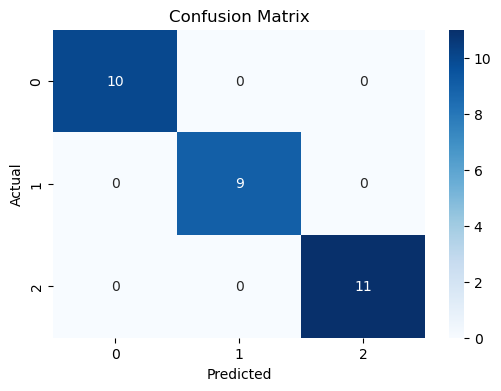

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(random_state=42)

model2.fit(X_train, y_train)

prediction2 = model2.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy2 = accuracy_score(y_test, prediction2)

print("Random Forest Accuracy:", accuracy2)

Random Forest Accuracy: 1.0


In [23]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", accuracy2)

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


## Conclusion

#### - Successfully loaded and analyzed the Iris dataset.
#### - Performed Exploratory Data Analysis (EDA).
#### - Visualized the dataset using Count Plot, Pair Plot, Box Plot, and Heatmap.
#### - Trained two machine learning models:
####  - Logistic Regression
####  - Random Forest Classifier
#### - Compared both models using accuracy.
#### - The best-performing model achieved excellent accuracy on the Iris dataset.